In [1]:
import json
import os
from pathlib import Path
from string import ascii_lowercase

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

if "MPL_STYLE" not in os.environ:
    os.environ["MPL_STYLE"] = "seaborn-v0_8-notebook"
plt.style.use(os.environ["MPL_STYLE"])


In [2]:
OUTPUT_BASE = Path(os.getenv("OUTPUT_BASE")).resolve(strict=True)
DATASET_NAME = os.getenv("DATASET_NAME", "M6")
DATASET_DIR = Path(
    os.getenv("DATASET_DIR", OUTPUT_BASE / "dataset" / DATASET_NAME)
).resolve(strict=True)
SHARD_KIND = os.getenv("SHARD_KIND", "raw")
SPLITS = ("train", "val", "test")

with open((DATASET_DIR / "dataset_config.json").resolve(strict=True), "r") as f:
    dataset_config = json.load(f)

TARGET_KEYS = tuple(dataset_config["target_keys"])
SPLIT_PLOT_CONFIG = {
    "train": {"label": "Train", "color": "#1f77b4"},
    "val": {"label": "Val.", "color": "#ff7f0e"},
    "test": {"label": "Test", "color": "#2ca02c"},
}
TARGET_PLOT_CONFIG = {
    "time": {
        "label": r"$t\;[\mathrm{Myr}]$",
        "bin_width": 15,
        "x_lim": (-30, 360),
        "x_major_locator": mpl.ticker.MultipleLocator(90),
        "x_minor_locator": mpl.ticker.MultipleLocator(30),
        "y_lim": (0, 0.012),
        "y_major_locator": mpl.ticker.MultipleLocator(0.004, offset=0.002),
        "y_minor_locator": mpl.ticker.MultipleLocator(0.001),
    },
    "total_mass_within_2x_r_tidal": {
        "label": r"$M_{\mathrm{total}}\;[M_\odot]$",
        "bin_width": 10,
        "x_lim": (-20, 240),
        "x_major_locator": mpl.ticker.MultipleLocator(60),
        "x_minor_locator": mpl.ticker.MultipleLocator(20),
        "y_lim": (0, 0.032),
        "y_major_locator": mpl.ticker.MultipleLocator(0.008, offset=0.004),
        "y_minor_locator": mpl.ticker.MultipleLocator(0.002),
    },
}


In [3]:
target_df_arr = []
for split in SPLITS:
    shard_path = (DATASET_DIR / f"{SHARD_KIND}-{split}-shard.npz").resolve(strict=True)
    with np.load(shard_path, allow_pickle=False) as shard:
        shard_target_keys = tuple(shard["target_keys"].tolist())
        if shard_target_keys != TARGET_KEYS:
            raise ValueError(
                f"Unexpected target keys for {split}: {shard_target_keys}; "
                f"expected {TARGET_KEYS}."
            )
        split_df = pd.DataFrame(shard["target"], columns=TARGET_KEYS)

    split_df.insert(0, "split", split)
    target_df_arr.append(split_df)

target_df = pd.concat(target_df_arr, ignore_index=True)
target_df["split"] = pd.Categorical(target_df["split"], categories=SPLITS, ordered=True)
summary_df = (
    target_df.groupby("split", observed=True)[list(TARGET_KEYS)]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(3)
)

print("dataset:", DATASET_DIR)
print("shard kind:", SHARD_KIND)
print("target keys:", TARGET_KEYS)
print("manifest sizes:", {split: len(dataset_config["manifest"][split]) for split in SPLITS})
summary_df


dataset: /home/yifan/Documents/projects/NBODY6-inference/output-ml/dataset/M6
shard kind: raw
target keys: ('time', 'total_mass_within_2x_r_tidal')
manifest sizes: {'train': 1940, 'val': 603, 'test': 330}


time                                                    \
         count       mean        std  min     median         max   
split                                                              
train  3112780  84.186996  68.663002  0.0  66.879997  304.854004   
val     861259  82.293999  67.587997  0.0  64.788002  295.450989   
test    416806  81.386002  68.624001  0.0  62.893002  304.854004   

      total_mass_within_2x_r_tidal                                          \
                             count       mean        std    min     median   
split                                                                        
train                      3112780  38.418999  32.629002  2.458  27.634001   
val                         861259  38.397999  32.444000  3.099  27.636999   
test                        416806  38.646999  32.742001  3.101  27.652000   

                   
              max  
split              
train  219.942993  
val    214.384995  
test   213.824005

## Visualization


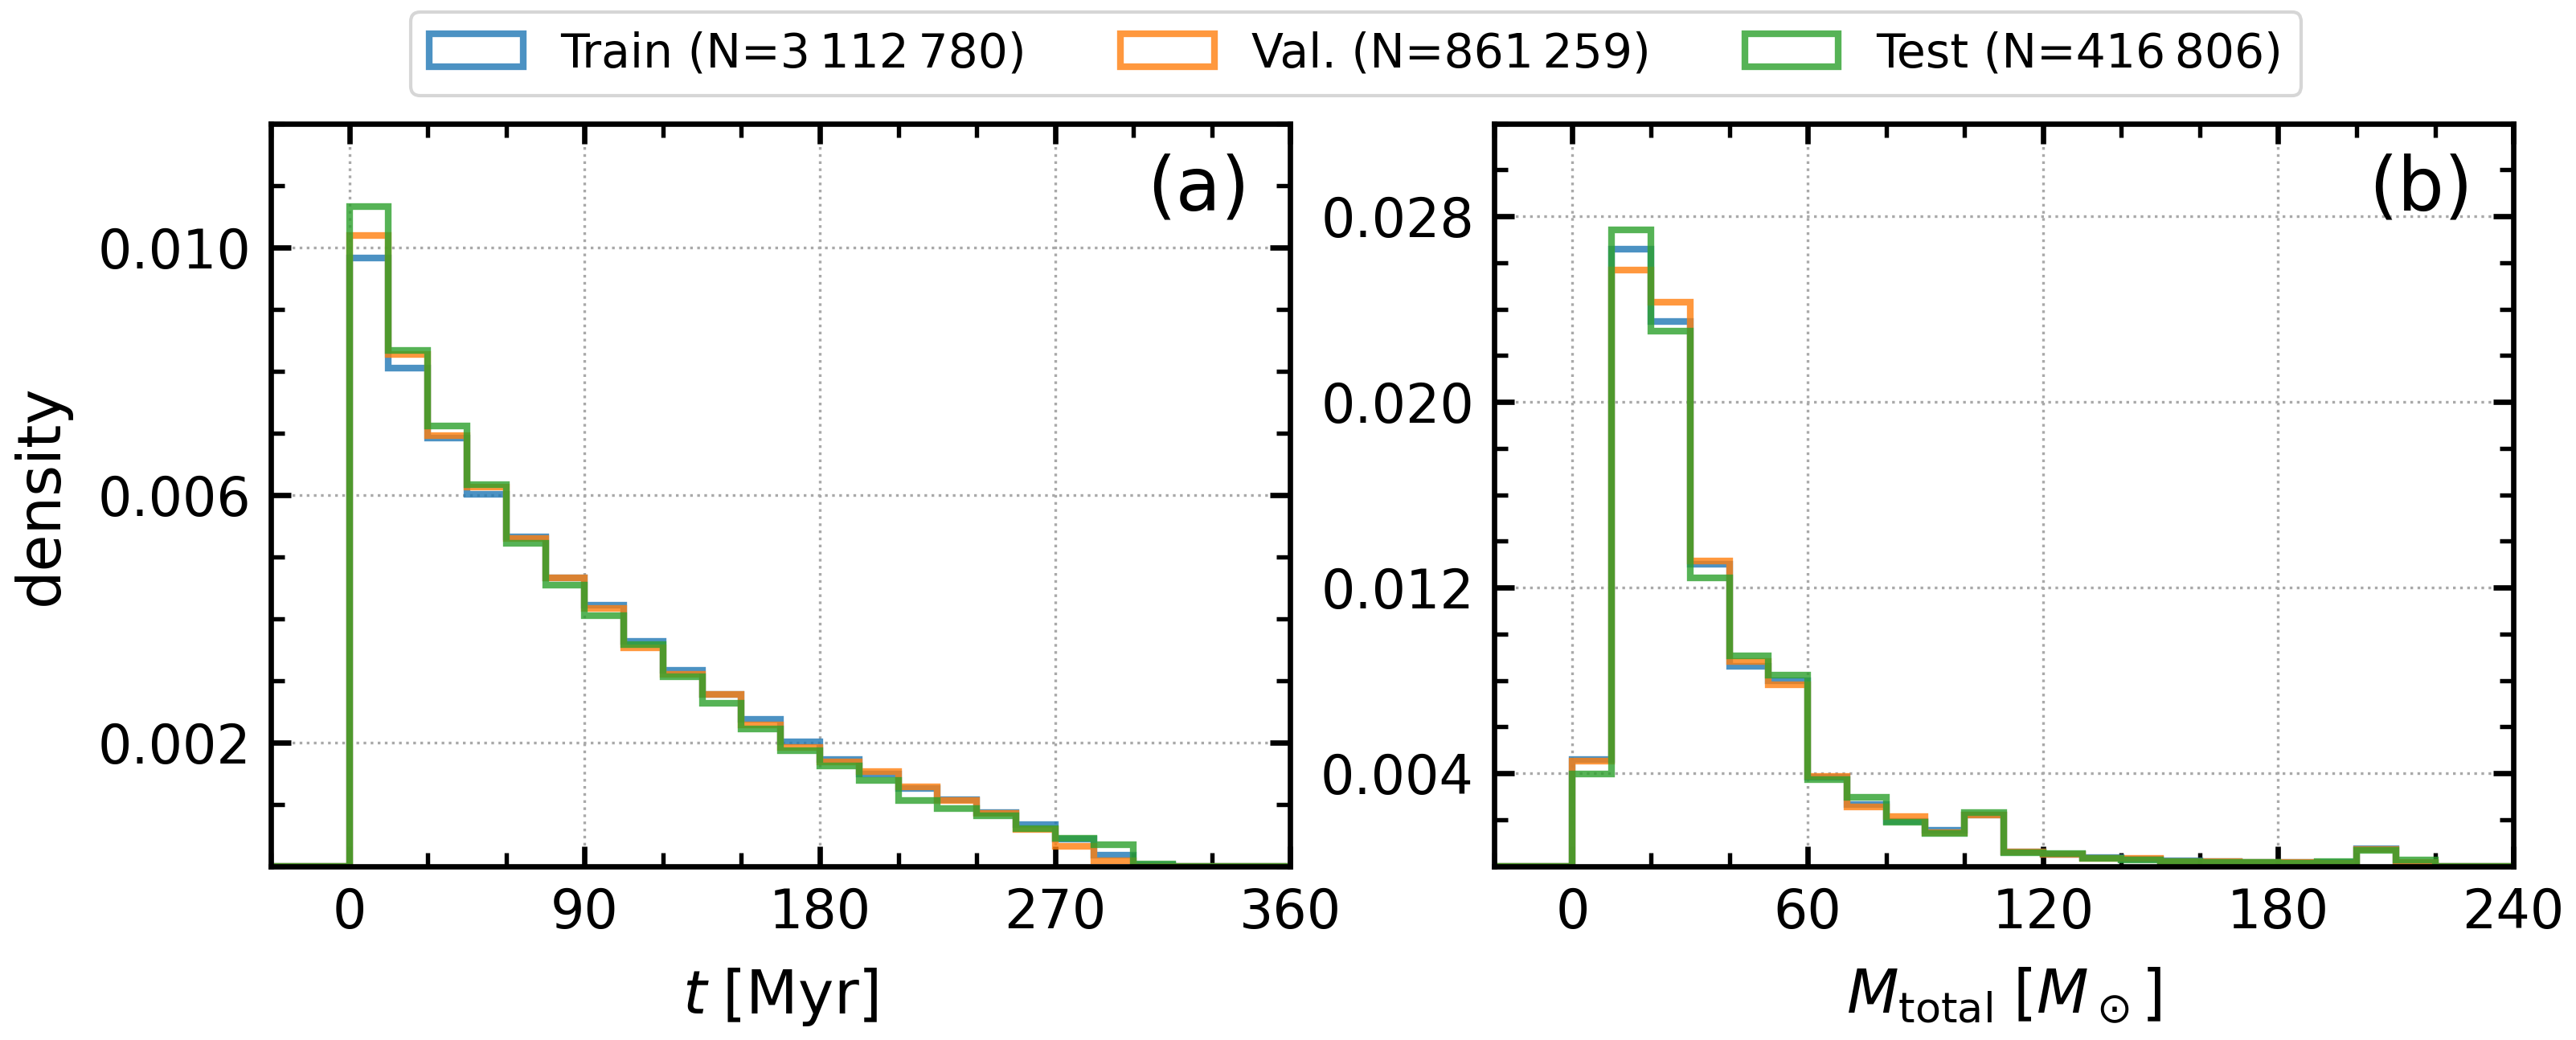

In [4]:
fig, axs = plt.subplots(
    1,
    len(TARGET_KEYS),
    figsize=(6 * len(TARGET_KEYS), 4),
    dpi=300,
    squeeze=False,
)
legend_handles = {}
legend_labels = {}

for ax_idx, (ax, target_key) in enumerate(zip(axs.ravel(), TARGET_KEYS)):
    plot_cfg = TARGET_PLOT_CONFIG[target_key]
    x_min, x_max = plot_cfg["x_lim"]
    bins = np.arange(x_min, x_max + plot_cfg["bin_width"], plot_cfg["bin_width"])

    for split, split_cfg in SPLIT_PLOT_CONFIG.items():
        split_values = target_df.loc[target_df["split"] == split, target_key].dropna()
        split_values = split_values[(split_values >= x_min) & (split_values <= x_max)]
        label = f"{split_cfg['label']} (N={len(split_values):,})".replace(
            ",", "\N{THIN SPACE}"
        )

        _, _, patches = ax.hist(
            split_values,
            bins=bins,
            density=True,
            histtype="step",
            color=split_cfg["color"],
            facecolor="none",
            linewidth=2,
            alpha=0.8,
        )
        if ax_idx == 0:
            legend_handles[split] = patches[0]
            legend_labels[split] = label

    ax.text(
        0.96,
        0.96,
        f"({ascii_lowercase[ax_idx]})",
        transform=ax.transAxes,
        fontsize=22,
        va="top",
        ha="right",
    )
    ax.set_xlabel(plot_cfg["label"])
    ax.set_xlim(plot_cfg["x_lim"])
    ax.xaxis.set_major_locator(plot_cfg["x_major_locator"])
    ax.xaxis.set_minor_locator(plot_cfg["x_minor_locator"])

    ax.set_ylabel("density" if ax_idx == 0 else "")
    ax.set_ylim(plot_cfg["y_lim"])
    ax.yaxis.set_major_locator(plot_cfg["y_major_locator"])
    ax.yaxis.set_minor_locator(plot_cfg["y_minor_locator"])

    ax.tick_params(axis="both", which="major")
    ax.tick_params(axis="both", which="minor")
    ax.grid(ls=":", lw=0.8, c="darkgrey")

fig.legend(
    [legend_handles[split] for split in SPLITS],
    [legend_labels[split] for split in SPLITS],
    loc="upper center",
    ncol=len(SPLITS),
    bbox_to_anchor=(0.5, 1.02),
    fontsize=14,
)
fig.savefig(OUTPUT_BASE / f"{DATASET_NAME}-target_dist.pdf", bbox_inches="tight")
